# Semana 10: Deep learning y arquitecturas basicas
### Fundamentos de IA y Machine Learning (92-0025) | ULACIT
### Microcredencial en Inteligencia Artificial y Analisis de Datos para Negocios

---

**Objetivo de esta sesion:** Comprender las diferencias entre ML tradicional y deep learning, construir redes neuronales profundas, experimentar con hiperparametros de optimizacion y regularizacion, y conectar todo esto con decisiones de negocio reales.

**Modalidad:** En lugar de una presentacion teorica tradicional, vamos a **aprender haciendo**. Cada concepto se introduce, se ejecuta y se analiza en tiempo real.

---

## 0. Preparacion del entorno

Primero instalamos e importamos todo lo necesario. Este notebook usa **TensorFlow/Keras**, que viene preinstalado en Google Colab.

In [8]:
# Importaciones principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Machine Learning tradicional
from sklearn.datasets import make_moons, make_circles, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# Configuracion para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Colores ULACIT para graficos
PURPLE = '#2D1B4E'
CYAN = '#00D4FF'
LIGHT_PURPLE = '#6B4F8A'
LIGHT_CYAN = '#7AEAFF'
GRAY = '#888888'
RED = '#E74C3C'
GREEN = '#2ECC71'
ORANGE = '#F39C12'

print(f"TensorFlow version: {tf.__version__}")
print("Entorno listo para la sesion.")

TensorFlow version: 2.21.0
Entorno listo para la sesion.


---
## 1. ML tradicional vs. deep learning: una comparacion visual

### La pregunta de negocio

Imaginemos que somos directores de operaciones de una empresa y necesitamos clasificar datos. A veces los patrones son simples (como separar clientes por ingreso y edad), pero a veces los patrones son **complejos y no lineales** (como detectar fraude, defectos en imagenes o sentimiento en texto).

Vamos a crear datos con patrones cada vez mas complejos y ver como responde cada enfoque.

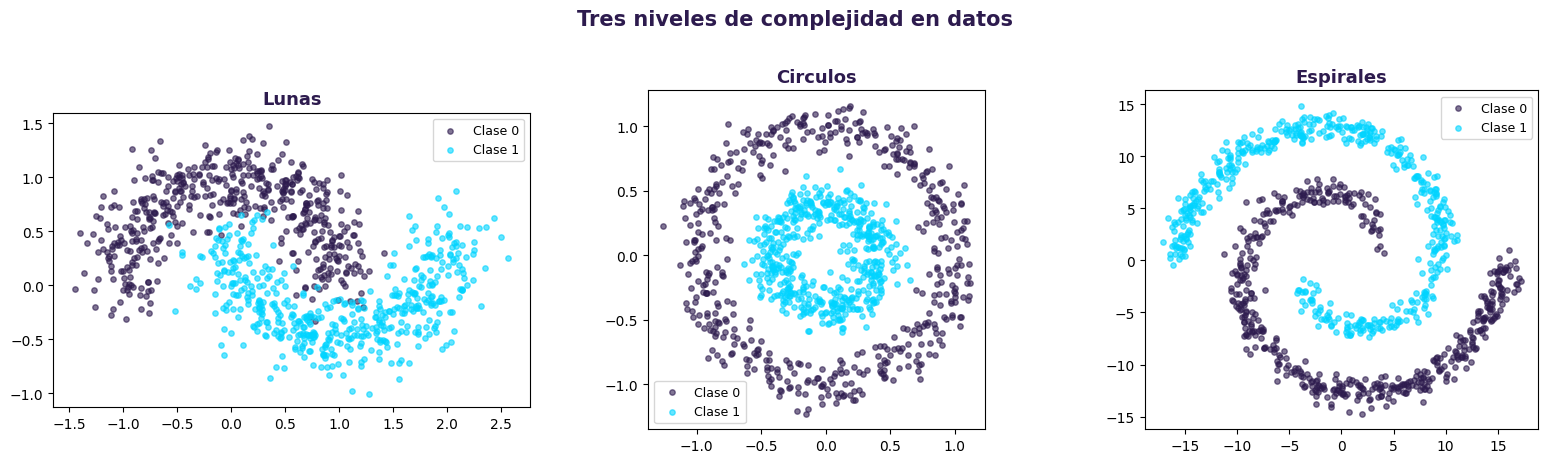

In [11]:
# Generamos tres datasets con complejidad creciente
# 1. Lunas (complejidad media)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=42)

# 2. Circulos concentricos (complejidad alta)
X_circles, y_circles = make_circles(n_samples=1000, noise=0.1, factor=0.4, random_state=42)

# 3. Espiral doble (complejidad muy alta)
def make_spirals(n_samples=500, noise=0.5):
    n = n_samples // 2
    theta = np.sqrt(np.random.rand(n)) * 2 * np.pi
    r_a = 2 * theta + np.pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
    x_a = data_a + np.random.randn(n, 2) * noise
    r_b = -2 * theta - np.pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
    x_b = data_b + np.random.randn(n, 2) * noise
    X = np.vstack([x_a, x_b])
    y = np.hstack([np.zeros(n), np.ones(n)])
    return X, y.astype(int)

X_spiral, y_spiral = make_spirals(1000, noise=0.7)

# Visualizamos los tres datasets
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
datasets = [(X_moons, y_moons, 'Lunas'), (X_circles, y_circles, 'Circulos'), (X_spiral, y_spiral, 'Espirales')]

for ax, (X, y, title) in zip(axes, datasets):
    ax.scatter(X[y==0, 0], X[y==0, 1], c=PURPLE, alpha=0.6, s=15, label='Clase 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c=CYAN, alpha=0.6, s=15, label='Clase 1')
    ax.set_title(title, fontsize=13, fontweight='bold', color=PURPLE)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Tres niveles de complejidad en datos', fontsize=15, fontweight='bold', color=PURPLE, y=1.02)
plt.tight_layout()
plt.show()

### Pregunta para reflexion

Observen los tres datasets. Si tuvieran que dibujar una linea recta para separar las dos clases, en cual funcionaria? En cual no? Eso nos lleva al concepto clave: **no linealidad**.

---

### Ahora comparemos: regresion logistica vs. red neuronal

NameError: name 'datasets' is not defined

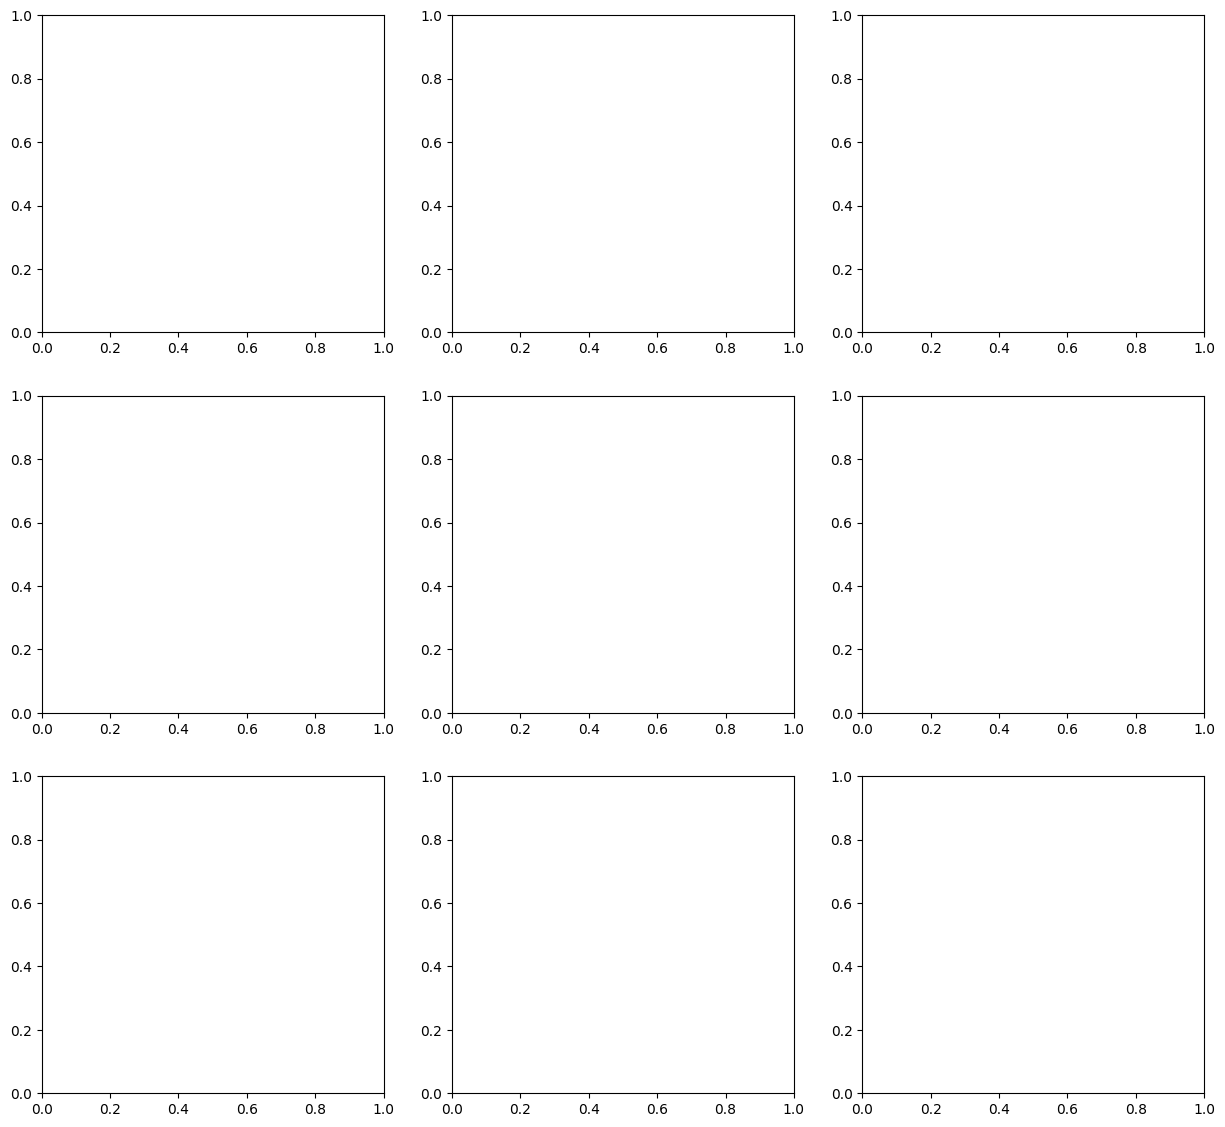

In [10]:
def plot_decision_boundary(model, X, y, ax, title, is_keras=False):
    """Dibuja la frontera de decision de un modelo."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_keras:
        Z = (model.predict(grid, verbose=0) > 0.5).astype(int).ravel()
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[y==0, 0], X[y==0, 1], c=PURPLE, alpha=0.6, s=10, edgecolors='white', linewidths=0.3)
    ax.scatter(X[y==1, 0], X[y==1, 1], c=CYAN, alpha=0.6, s=10, edgecolors='white', linewidths=0.3)
    ax.set_title(title, fontsize=10, fontweight='bold')


def build_simple_nn(input_dim, hidden_layers=[32, 16], activation='relu'):
    """Construye una red neuronal simple."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


# Comparacion en los tres datasets
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
for row, (X, y, name) in enumerate(datasets):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 1. Regresion logistica (ML lineal)
    lr = LogisticRegression(random_state=42)
    lr.fit(X_scaled, y)
    acc_lr = accuracy_score(y, lr.predict(X_scaled))
    plot_decision_boundary(lr, X_scaled, y, axes[row, 0],
                          f'Reg. logistica ({name})\nPrecision: {acc_lr:.1%}')

    # 2. Random Forest (ML no lineal)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_scaled, y)
    acc_rf = accuracy_score(y, rf.predict(X_scaled))
    plot_decision_boundary(rf, X_scaled, y, axes[row, 1],
                          f'Random Forest ({name})\nPrecision: {acc_rf:.1%}')

    # 3. Red neuronal profunda
    nn = build_simple_nn(2, hidden_layers=[64, 32, 16])
    nn.fit(X_scaled, y, epochs=100, batch_size=32, verbose=0)
    acc_nn = accuracy_score(y, (nn.predict(X_scaled, verbose=0) > 0.5).astype(int))
    plot_decision_boundary(nn, X_scaled, y, axes[row, 2],
                          f'Red neuronal profunda ({name})\nPrecision: {acc_nn:.1%}', is_keras=True)

# Etiquetas de columna
for j, label in enumerate(['ML lineal', 'ML no lineal (ensemble)', 'Deep Learning']):
    axes[0, j].annotate(label, xy=(0.5, 1.15), xycoords='axes fraction',
                        ha='center', fontsize=12, fontweight='bold', color=PURPLE)

plt.suptitle('Comparacion: ML tradicional vs. deep learning\nFronteras de decision en datos con complejidad creciente',
             fontsize=14, fontweight='bold', color=PURPLE, y=1.02)
plt.tight_layout()
plt.show()

### Lectura clave de este grafico

| Enfoque | Fortaleza | Limitacion |
|---|---|---|
| **Regresion logistica** | Rapida, interpretable, ideal para patrones lineales | No puede capturar relaciones complejas |
| **Random Forest** | Captura no linealidad, robusto | Fronteras "cuadradas", requiere feature engineering manual |
| **Red neuronal profunda** | Aprende patrones arbitrariamente complejos | Requiere mas datos y computo, menos interpretable |

**Analogia de negocio:** La regresion logistica es como analizar ventas con una hoja de calculo. Random Forest es como contratar un equipo de analistas experimentados. Deep learning es como tener un sistema que descubre patrones que ningun analista veria, pero necesita mucha mas inversion.

---

### Cuando usar cada enfoque: guia para tomadores de decisiones

| Criterio | ML tradicional | Deep learning |
|---|---|---|
| **Datos** | Tablas, hojas de calculo | Imagenes, texto, audio, video |
| **Volumen** | Desde 50 registros | 10,000+ registros (idealmente millones) |
| **Hardware** | CPU estandar | GPUs o TPUs |
| **Interpretabilidad** | Alta (se puede explicar cada decision) | Baja ("caja negra") |
| **Costo** | Bajo | Alto |
| **Feature engineering** | Manual (requiere expertos) | Automatico (el modelo aprende) |

**Dato 2025-2026:** El EU AI Act (vigente desde febrero 2025) exige transparencia en sistemas de IA de alto riesgo. Esto favorece al ML tradicional en contextos regulados como credito, salud y seguros.

---
## 2. Construyendo una red neuronal profunda paso a paso

### El dataset: diagnostico de cancer de mama

Usaremos el **Breast Cancer Wisconsin Dataset** de scikit-learn. Este dataset contiene 569 muestras de tumores con 30 caracteristicas numericas. La tarea es clasificar cada tumor como **maligno** o **benigno**.

Es un escenario real donde las decisiones de un modelo impactan directamente en vidas humanas, similar a como los dispositivos medicos (una industria clave en Costa Rica) dependen de sistemas de control de calidad precisos.

In [12]:
# Cargamos el dataset
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = maligno, 1 = benigno
feature_names = data.feature_names

print(f"Dimensiones del dataset: {X.shape}")
print(f"  - {X.shape[0]} muestras (tumores)")
print(f"  - {X.shape[1]} caracteristicas por muestra")
print(f"\nDistribucion de clases:")
print(f"  - Malignos: {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f"  - Benignos: {(y == 1).sum()} ({(y == 1).mean():.1%})")
print(f"\nAlgunas caracteristicas: {list(feature_names[:5])}...")

Dimensiones del dataset: (569, 30)
  - 569 muestras (tumores)
  - 30 caracteristicas por muestra

Distribucion de clases:
  - Malignos: 212 (37.3%)
  - Benignos: 357 (62.7%)

Algunas caracteristicas: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]...


In [13]:
# Preparacion de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalamiento (CRITICO para redes neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos de entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Datos de prueba: {X_test_scaled.shape[0]} muestras")
print(f"\nAntes de escalar - Media: {X_train[:, 0].mean():.2f}, Desv. est.: {X_train[:, 0].std():.2f}")
print(f"Despues de escalar - Media: {X_train_scaled[:, 0].mean():.4f}, Desv. est.: {X_train_scaled[:, 0].std():.4f}")

Datos de entrenamiento: 455 muestras
Datos de prueba: 114 muestras

Antes de escalar - Media: 14.07, Desv. est.: 3.50
Despues de escalar - Media: -0.0000, Desv. est.: 1.0000


### Por que es critico escalar los datos?

Las redes neuronales aprenden ajustando pesos. Si una caracteristica tiene valores entre 0-1000 y otra entre 0-1, la red le dara demasiada importancia a la primera simplemente por su escala, no por su relevancia.

**Analogia de negocio:** Es como comparar ingresos en colones vs. dolares sin hacer conversion. Los numeros grandes dominarian el analisis.

### Baseline con ML tradicional

Antes de usar deep learning, veamos que tan bien funcionan los modelos clasicos. Esto nos da un **punto de referencia** para evaluar si la complejidad adicional del deep learning vale la pena.

In [15]:
# Modelos de ML tradicional como baseline
modelos_ml = {
    'Regresion logistica': LogisticRegression(max_iter=1000, random_state=42),
    'Arbol de decision': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print("=" * 55)
print("BASELINE: Modelos de ML tradicional")
print("=" * 55)

resultados_ml = {}
for nombre, modelo in modelos_ml.items():
    modelo.fit(X_train_scaled, y_train)
    acc_train = modelo.score(X_train_scaled, y_train)
    acc_test = modelo.score(X_test_scaled, y_test)
    resultados_ml[nombre] = {'train': acc_train, 'test': acc_test}
    brecha = acc_train - acc_test
    print(f"\n{nombre}:")
    print(f"  Train: {acc_train:.4f} | Test: {acc_test:.4f} | Brecha: {brecha:.4f}")

BASELINE: Modelos de ML tradicional

Regresion logistica:
  Train: 0.9890 | Test: 0.9825 | Brecha: 0.0066

Arbol de decision:
  Train: 1.0000 | Test: 0.9123 | Brecha: 0.0877

Random Forest:
  Train: 1.0000 | Test: 0.9561 | Brecha: 0.0439

Gradient Boosting:
  Train: 1.0000 | Test: 0.9561 | Brecha: 0.0439


### Ahora construyamos redes neuronales con profundidad creciente

La "profundidad" de una red neuronal se refiere al numero de capas ocultas. Mas capas permiten aprender patrones mas complejos, pero tambien aumentan el riesgo de **sobreajuste** y el costo computacional.

Vamos a construir 4 redes con profundidad creciente y comparar.

In [16]:
def build_and_train_nn(X_train, y_train, X_test, y_test,
                       hidden_layers, name, epochs=100):
    """Construye, entrena y devuelve el historial de una red neuronal."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=32,
        verbose=0
    )

    return model, history


# Definimos 4 arquitecturas con profundidad creciente
arquitecturas = {
    'Red superficial\n(1 capa, 16 neuronas)': [16],
    'Red moderada\n(2 capas, 64-32)': [64, 32],
    'Red profunda\n(4 capas, 128-64-32-16)': [128, 64, 32, 16],
    'Red muy profunda\n(6 capas, 256-128-64-32-16-8)': [256, 128, 64, 32, 16, 8]
}

resultados_nn = {}
historiales = {}

print("Entrenando 4 redes con profundidad creciente...\n")

for nombre, capas in arquitecturas.items():
    model, history = build_and_train_nn(
        X_train_scaled, y_train, X_test_scaled, y_test,
        hidden_layers=capas, name=nombre, epochs=150
    )
    n_params = model.count_params()
    acc_train = history.history['accuracy'][-1]
    acc_test = history.history['val_accuracy'][-1]
    resultados_nn[nombre] = {'train': acc_train, 'test': acc_test, 'params': n_params}
    historiales[nombre] = history
    print(f"{nombre.replace(chr(10), ' ')}")
    print(f"  Parametros: {n_params:,} | Train: {acc_train:.4f} | Test: {acc_test:.4f}")
    print()

Entrenando 4 redes con profundidad creciente...

Red superficial (1 capa, 16 neuronas)
  Parametros: 513 | Train: 0.9934 | Test: 0.9561

Red moderada (2 capas, 64-32)
  Parametros: 4,097 | Train: 1.0000 | Test: 0.9561

Red profunda (4 capas, 128-64-32-16)
  Parametros: 14,849 | Train: 1.0000 | Test: 0.9561

Red muy profunda (6 capas, 256-128-64-32-16-8)
  Parametros: 51,841 | Train: 1.0000 | Test: 0.9737



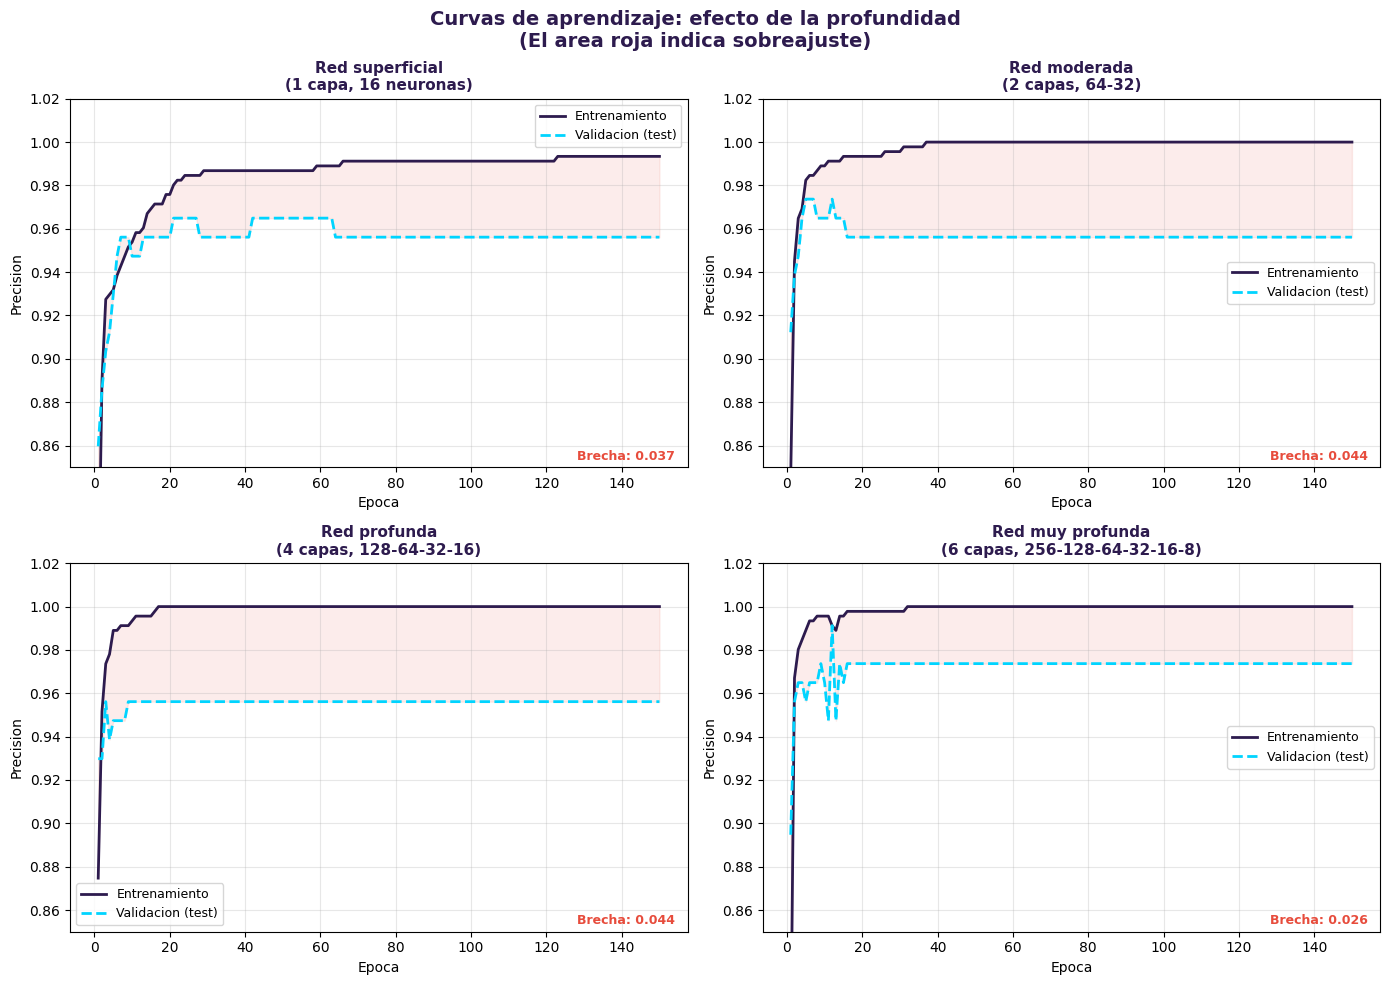

In [17]:
# Visualizamos las curvas de aprendizaje
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_train = [PURPLE, PURPLE, PURPLE, PURPLE]
colors_val = [CYAN, CYAN, CYAN, CYAN]

for idx, (nombre, history) in enumerate(historiales.items()):
    ax = axes[idx // 2, idx % 2]
    epochs_range = range(1, len(history.history['accuracy']) + 1)

    ax.plot(epochs_range, history.history['accuracy'], color=PURPLE,
            linewidth=2, label='Entrenamiento')
    ax.plot(epochs_range, history.history['val_accuracy'], color=CYAN,
            linewidth=2, label='Validacion (test)', linestyle='--')

    # Sombrear la brecha (indica overfitting)
    ax.fill_between(epochs_range,
                    history.history['accuracy'],
                    history.history['val_accuracy'],
                    alpha=0.1, color=RED)

    ax.set_title(nombre, fontsize=11, fontweight='bold', color=PURPLE)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=9)
    ax.set_ylim(0.85, 1.02)
    ax.grid(True, alpha=0.3)

    # Anotar la brecha final
    train_final = history.history['accuracy'][-1]
    test_final = history.history['val_accuracy'][-1]
    brecha = train_final - test_final
    ax.annotate(f'Brecha: {brecha:.3f}', xy=(0.98, 0.02), xycoords='axes fraction',
                ha='right', fontsize=9, color=RED, fontweight='bold')

plt.suptitle('Curvas de aprendizaje: efecto de la profundidad\n(El area roja indica sobreajuste)',
             fontsize=14, fontweight='bold', color=PURPLE)
plt.tight_layout()
plt.show()

### Lectura clave

Observen como a medida que la red se hace mas profunda:
- La **precision de entrenamiento** sube (la red memoriza mejor)
- La **brecha** entre entrenamiento y validacion puede aumentar (sobreajuste)
- Mas parametros no siempre significan mejor rendimiento real

**Analogia de negocio:** Es como contratar mas y mas consultores para un proyecto. Llega un punto donde agregar mas personas no mejora el resultado sino que genera confunsion y costos innecesarios. La clave es encontrar la complejidad justa.

---

## 3. Optimizacion: el motor del aprendizaje

### Que es gradient descent?

Gradient descent es el algoritmo que permite a las redes neuronales **aprender**. Funciona asi:

1. La red hace una prediccion (probablemente mala al inicio)
2. Se calcula el error (funcion de perdida)
3. Se calculan los gradientes ("en que direccion y cuanto ajustar cada peso")
4. Se actualizan los pesos un poquito en esa direccion
5. Se repite miles de veces

Los **hiperparametros** clave que controlan este proceso son:
- **Learning rate**: que tan grande es cada paso de ajuste
- **Batch size**: cuantas muestras ve antes de ajustar
- **Optimizador**: la estrategia de ajuste (SGD, Adam, etc.)

### 3.1 Efecto del learning rate

In [18]:
# Experimentamos con diferentes learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_labels = ['0.0001 (muy bajo)', '0.001 (optimo tipico)', '0.01 (alto)', '0.1 (muy alto)']
lr_histories = {}

print("Entrenando con diferentes learning rates...\n")

for lr, label in zip(learning_rates, lr_labels):
    model = keras.Sequential([
        layers.Input(shape=(30,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(X_train_scaled, y_train,
                       validation_data=(X_test_scaled, y_test),
                       epochs=100, batch_size=32, verbose=0)
    lr_histories[label] = history
    final_acc = history.history['val_accuracy'][-1]
    print(f"LR = {label}: Precision final = {final_acc:.4f}")

Entrenando con diferentes learning rates...

LR = 0.0001 (muy bajo): Precision final = 0.9561
LR = 0.001 (optimo tipico): Precision final = 0.9561
LR = 0.01 (alto): Precision final = 0.9561
LR = 0.1 (muy alto): Precision final = 0.9561


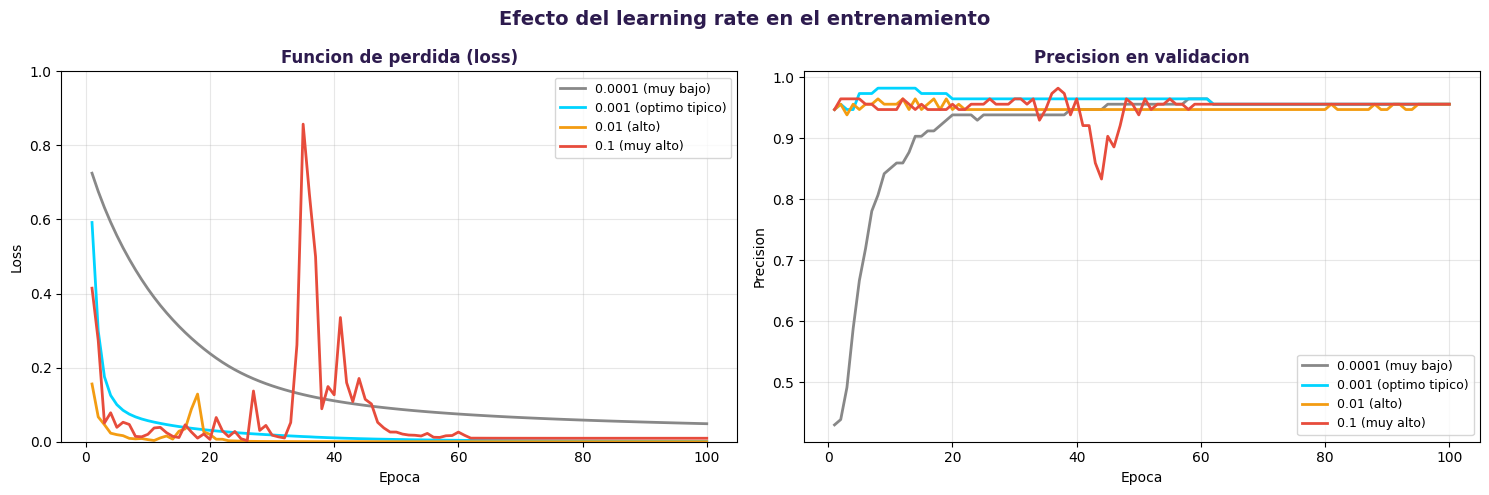

In [19]:
# Visualizacion del efecto del learning rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
colors_lr = [GRAY, CYAN, ORANGE, RED]

for (label, history), color in zip(lr_histories.items(), colors_lr):
    epochs = range(1, len(history.history['loss']) + 1)
    ax1.plot(epochs, history.history['loss'], color=color, linewidth=2, label=label)
    ax2.plot(epochs, history.history['val_accuracy'], color=color, linewidth=2, label=label)

ax1.set_title('Funcion de perdida (loss)', fontsize=12, fontweight='bold', color=PURPLE)
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.0)

ax2.set_title('Precision en validacion', fontsize=12, fontweight='bold', color=PURPLE)
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Precision')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Efecto del learning rate en el entrenamiento',
             fontsize=14, fontweight='bold', color=PURPLE)
plt.tight_layout()
plt.show()

### Interpretacion del learning rate

| Learning rate | Comportamiento | Analogia de negocio |
|---|---|---|
| **Muy bajo** (0.0001) | Aprende muy lento, puede no converger | Ajustar presupuesto en incrementos de 100 colones |
| **Optimo** (~0.001) | Aprendizaje estable y eficiente | Ajustes estrategicos medidos |
| **Alto** (0.01) | Aprende rapido pero inestable | Cambios bruscos de estrategia cada semana |
| **Muy alto** (0.1) | Oscila sin converger, puede divergir | Cambiar toda la estrategia de negocio cada dia |

**Dato 2025-2026:** El optimizador **Muon** (2025) logra el doble de eficiencia computacional que Adam, reduciendo costos de entrenamiento hasta un 50%. Los modelos mas grandes del mundo aun usan **AdamW** como estandar.

### 3.2 Efecto del batch size

In [20]:
# Experimentamos con diferentes batch sizes
batch_sizes = [4, 16, 32, 128, len(X_train_scaled)]  # El ultimo es "full batch"
batch_labels = ['4 (mini)', '16 (pequeno)', '32 (estandar)', '128 (grande)', f'{len(X_train_scaled)} (full batch)']
batch_histories = {}

print("Entrenando con diferentes batch sizes...\n")

for bs, label in zip(batch_sizes, batch_labels):
    model = keras.Sequential([
        layers.Input(shape=(30,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_scaled, y_train,
                       validation_data=(X_test_scaled, y_test),
                       epochs=100, batch_size=bs, verbose=0)
    batch_histories[label] = history
    final_acc = history.history['val_accuracy'][-1]
    print(f"Batch size = {label}: Precision final = {final_acc:.4f}")

Entrenando con diferentes batch sizes...

Batch size = 4 (mini): Precision final = 0.9561
Batch size = 16 (pequeno): Precision final = 0.9649
Batch size = 32 (estandar): Precision final = 0.9649
Batch size = 128 (grande): Precision final = 0.9561
Batch size = 455 (full batch): Precision final = 0.9298


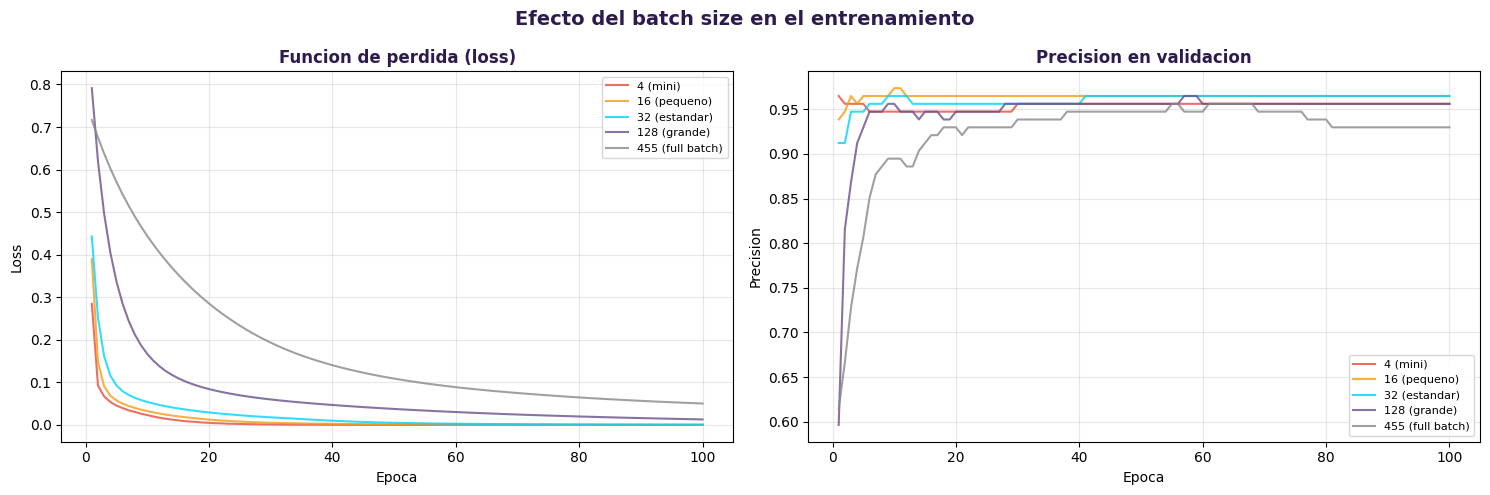

In [21]:
# Visualizacion del efecto del batch size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
colors_bs = [RED, ORANGE, CYAN, LIGHT_PURPLE, GRAY]

for (label, history), color in zip(batch_histories.items(), colors_bs):
    epochs = range(1, len(history.history['loss']) + 1)
    ax1.plot(epochs, history.history['loss'], color=color, linewidth=1.5, label=label, alpha=0.8)
    ax2.plot(epochs, history.history['val_accuracy'], color=color, linewidth=1.5, label=label, alpha=0.8)

ax1.set_title('Funcion de perdida (loss)', fontsize=12, fontweight='bold', color=PURPLE)
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_title('Precision en validacion', fontsize=12, fontweight='bold', color=PURPLE)
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Precision')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle('Efecto del batch size en el entrenamiento',
             fontsize=14, fontweight='bold', color=PURPLE)
plt.tight_layout()
plt.show()

### Interpretacion del batch size

| Batch size | Comportamiento | Analogia de negocio |
|---|---|---|
| **Pequeno** (4-16) | Actualizaciones frecuentes pero ruidosas, mejor generalizacion | Encuestar pocos clientes seguido: captas tendencias rapido pero con ruido |
| **Medio** (32-64) | Balance entre velocidad y estabilidad | Encuesta mensual representativa |
| **Grande** (128+) | Estable pero puede converger a minimos suboptimos | Censo anual: muy preciso pero lento y costoso |

**Regla practica:** Comenzar con batch size de 32 y experimentar. Si se duplica el batch size, considerar aumentar el learning rate proporcionalmente.

---

## 4. Regularizacion: evitando el sobreajuste

El **sobreajuste** (overfitting) ocurre cuando la red memoriza los datos de entrenamiento en vez de aprender patrones generalizables. Es como un estudiante que memoriza las respuestas del examen anterior pero no entiende la materia.

Las tecnicas de **regularizacion** son mecanismos para prevenirlo. Vamos a explorar las dos mas importantes: **dropout** y **batch normalization**.

### 4.1 Primero, creemos un problema de sobreajuste a proposito

In [22]:
# Red intencionalmente sobreajustada
# (demasiados parametros para la cantidad de datos)
model_overfit = keras.Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_overfit.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Parametros totales: {model_overfit.count_params():,}")
print(f"Muestras de entrenamiento: {len(X_train_scaled)}")
print(f"Ratio parametros/muestras: {model_overfit.count_params() / len(X_train_scaled):.0f}:1")
print("\n(Una red con mas parametros que datos es receta para sobreajuste)")

history_overfit = model_overfit.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200, batch_size=32, verbose=0
)

print(f"\nResultado:")
print(f"  Precision entrenamiento: {history_overfit.history['accuracy'][-1]:.4f}")
print(f"  Precision validacion:    {history_overfit.history['val_accuracy'][-1]:.4f}")
print(f"  Brecha (sobreajuste):    {history_overfit.history['accuracy'][-1] - history_overfit.history['val_accuracy'][-1]:.4f}")

Parametros totales: 190,465
Muestras de entrenamiento: 455
Ratio parametros/muestras: 419:1

(Una red con mas parametros que datos es receta para sobreajuste)

Resultado:
  Precision entrenamiento: 1.0000
  Precision validacion:    0.9649
  Brecha (sobreajuste):    0.0351


### 4.2 Dropout: "apagar" neuronas al azar

**Dropout** es una tecnica elegante: durante el entrenamiento, en cada paso, se "apagan" aleatoriamente un porcentaje de neuronas. Esto obliga a la red a no depender de ninguna neurona individual y a distribuir el conocimiento.

**Analogia de negocio:** Imaginemos una empresa donde cualquier dia, un porcentaje aleatorio de empleados falta al trabajo. La empresa se ve forzada a que ningun proceso dependa de una sola persona. El resultado: una organizacion mas resiliente.

In [23]:
# Red con dropout
model_dropout = keras.Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),  # Apaga 30% de neuronas aleatoriamente
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_dropout = model_dropout.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200, batch_size=32, verbose=0
)

print("Red con Dropout (30%/20%):")
print(f"  Precision entrenamiento: {history_dropout.history['accuracy'][-1]:.4f}")
print(f"  Precision validacion:    {history_dropout.history['val_accuracy'][-1]:.4f}")
print(f"  Brecha:                  {history_dropout.history['accuracy'][-1] - history_dropout.history['val_accuracy'][-1]:.4f}")

Red con Dropout (30%/20%):
  Precision entrenamiento: 1.0000
  Precision validacion:    0.9649
  Brecha:                  0.0351


### 4.3 Batch normalization: estabilizar el aprendizaje

**Batch normalization** normaliza las activaciones de cada capa durante el entrenamiento. Esto estabiliza y acelera el proceso de aprendizaje.

**Analogia de negocio:** En una linea de produccion, si la materia prima llega con calidades muy variables, cada estacion debe perder tiempo ajustandose. Batch normalization es como estandarizar la materia prima entre cada etapa del proceso.

In [25]:
# Red con batch normalization
model_batchnorm = keras.Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_batchnorm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_batchnorm = model_batchnorm.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200, batch_size=32, verbose=0
)

print("Red con Batch Normalization:")
print(f"  Precision entrenamiento: {history_batchnorm.history['accuracy'][-1]:.4f}")
print(f"  Precision validacion:    {history_batchnorm.history['val_accuracy'][-1]:.4f}")
print(f"  Brecha:                  {history_batchnorm.history['accuracy'][-1] - history_batchnorm.history['val_accuracy'][-1]:.4f}")

Red con Batch Normalization:
  Precision entrenamiento: 1.0000
  Precision validacion:    0.9649
  Brecha:                  0.0351


### 4.4 Combinando ambas tecnicas

In [26]:
# Red con dropout + batch normalization (las mejores practicas)
model_combined = keras.Sequential([
    layers.Input(shape=(30,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_combined.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Usamos early stopping como tecnica adicional
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history_combined = model_combined.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200, batch_size=32, verbose=0,
    callbacks=[early_stop]
)

print("Red con Dropout + BatchNorm + Early Stopping:")
print(f"  Precision entrenamiento: {history_combined.history['accuracy'][-1]:.4f}")
print(f"  Precision validacion:    {history_combined.history['val_accuracy'][-1]:.4f}")
print(f"  Brecha:                  {history_combined.history['accuracy'][-1] - history_combined.history['val_accuracy'][-1]:.4f}")
print(f"  Epocas entrenadas:       {len(history_combined.history['accuracy'])} (de 200 maximas)")

Red con Dropout + BatchNorm + Early Stopping:
  Precision entrenamiento: 0.9978
  Precision validacion:    0.9561
  Brecha:                  0.0417
  Epocas entrenadas:       26 (de 200 maximas)


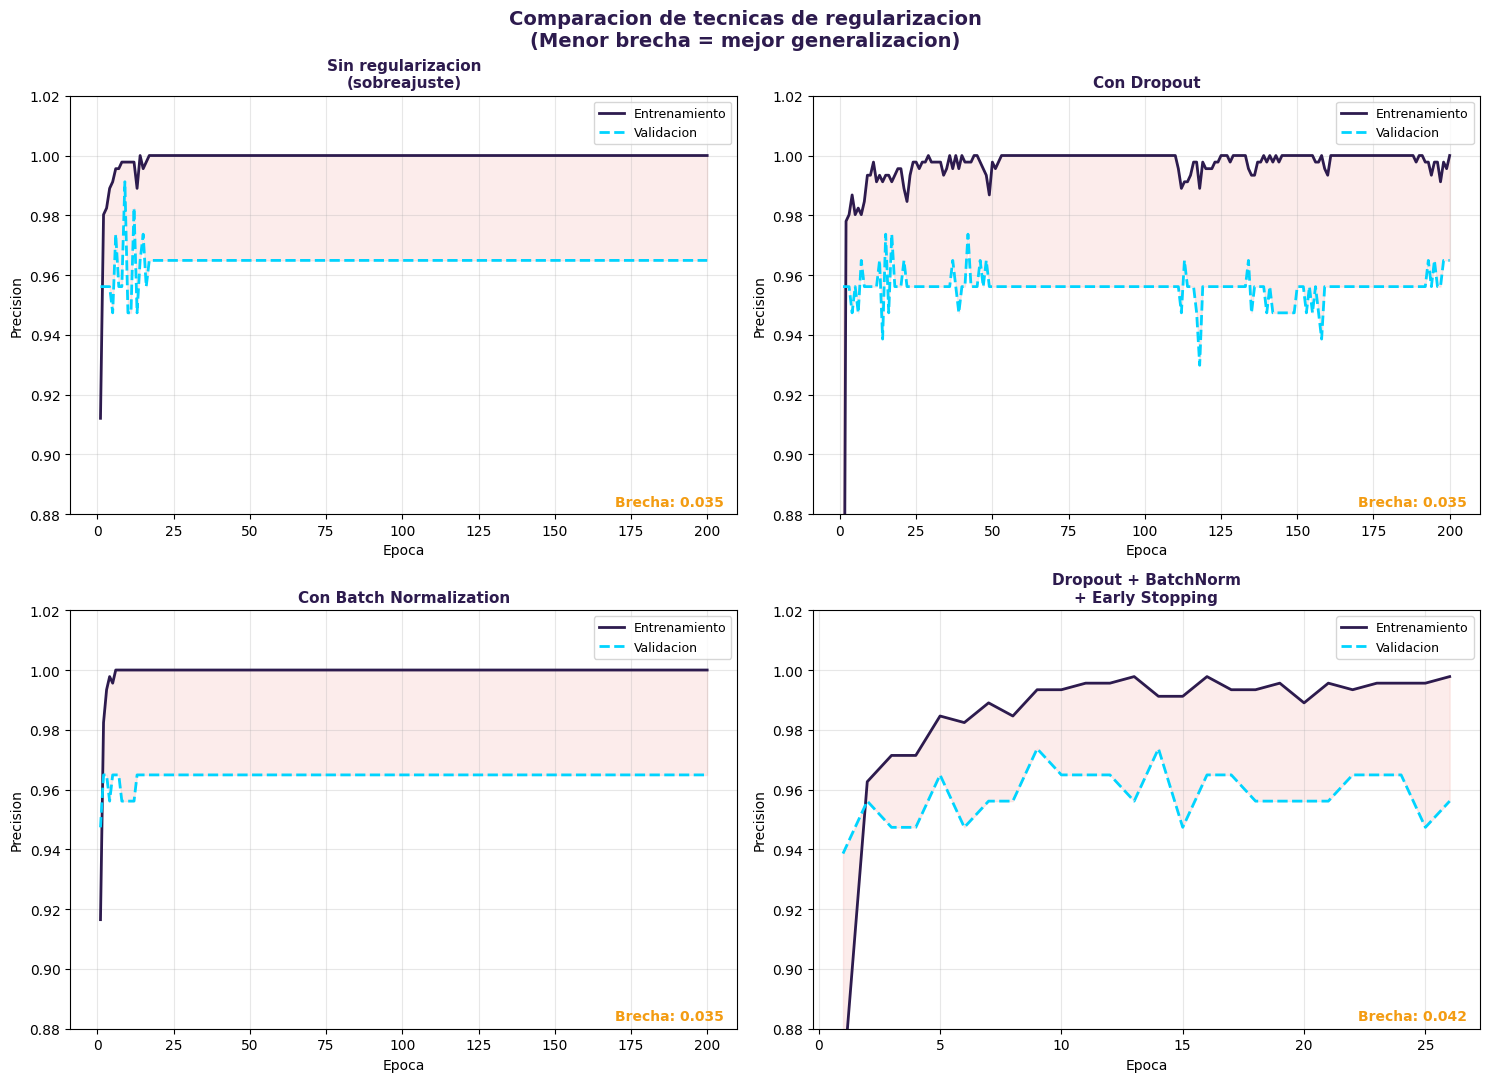

In [27]:
# Comparacion visual de todas las estrategias de regularizacion
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

all_histories = {
    'Sin regularizacion\n(sobreajuste)': history_overfit,
    'Con Dropout': history_dropout,
    'Con Batch Normalization': history_batchnorm,
    'Dropout + BatchNorm\n+ Early Stopping': history_combined
}

for idx, (nombre, history) in enumerate(all_histories.items()):
    ax = axes[idx // 2, idx % 2]
    epochs = range(1, len(history.history['accuracy']) + 1)

    ax.plot(epochs, history.history['accuracy'], color=PURPLE,
            linewidth=2, label='Entrenamiento')
    ax.plot(epochs, history.history['val_accuracy'], color=CYAN,
            linewidth=2, label='Validacion', linestyle='--')
    ax.fill_between(epochs, history.history['accuracy'],
                    history.history['val_accuracy'], alpha=0.1, color=RED)

    ax.set_title(nombre, fontsize=11, fontweight='bold', color=PURPLE)
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=9)
    ax.set_ylim(0.88, 1.02)
    ax.grid(True, alpha=0.3)

    # Brecha final
    brecha = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    color_brecha = GREEN if abs(brecha) < 0.02 else (ORANGE if abs(brecha) < 0.05 else RED)
    ax.annotate(f'Brecha: {brecha:.3f}', xy=(0.98, 0.02), xycoords='axes fraction',
                ha='right', fontsize=10, color=color_brecha, fontweight='bold')

plt.suptitle('Comparacion de tecnicas de regularizacion\n(Menor brecha = mejor generalizacion)',
             fontsize=14, fontweight='bold', color=PURPLE)
plt.tight_layout()
plt.show()

### Resumen de tecnicas de regularizacion

| Tecnica | Que hace | Cuando usarla | Analogia de negocio |
|---|---|---|---|
| **Dropout** | Apaga neuronas aleatoriamente | Siempre (tasa 0.1-0.5) | Cross-training de empleados |
| **Batch Normalization** | Estandariza activaciones entre capas | Redes profundas (4+ capas) | Control de calidad entre etapas |
| **Early stopping** | Detiene entrenamiento cuando empeora validacion | Siempre (es gratis) | Saber cuando dejar de invertir |
| **Weight decay** | Penaliza pesos grandes | Estandar en optimizadores modernos | Penalizar complejidad innecesaria |

**Dato 2025:** En los modelos mas modernos (LLaMA, Gemma, etc.), la tecnica de normalizacion dominante ya no es BatchNorm sino **RMSNorm**, una version simplificada que solo calcula la raiz cuadrada de la media de los cuadrados, sin centrar. Es mas rapida y funciona igual de bien.

---

## 5. Comparacion final: ML tradicional vs. deep learning en este dataset

In [29]:
# Resumen comparativo completo
print("=" * 65)
print("COMPARACION FINAL: ML tradicional vs. Deep Learning")
print("Dataset: Breast Cancer Wisconsin (569 muestras, 30 features)")
print("=" * 65)

# Recopilamos todos los resultados
todos = {}

# ML tradicional
for nombre, res in resultados_ml.items():
    todos[nombre] = res

# Deep Learning (mejor modelo)
todos['DL (sin regularizacion)'] = {
    'train': history_overfit.history['accuracy'][-1],
    'test': history_overfit.history['val_accuracy'][-1]
}
todos['DL (con regularizacion)'] = {
    'train': history_combined.history['accuracy'][-1],
    'test': history_combined.history['val_accuracy'][-1]
}

print(f"\n{'Modelo':<30} {'Train':>8} {'Test':>8} {'Brecha':>8}")
print("-" * 56)
for nombre, res in todos.items():
    brecha = res['train'] - res['test']
    indicador = ' <<<' if brecha > 0.05 else ''
    print(f"{nombre:<30} {res['train']:>8.4f} {res['test']:>8.4f} {brecha:>8.4f}{indicador}")

print("\n<<< = posible sobreajuste (brecha > 5%)")

COMPARACION FINAL: ML tradicional vs. Deep Learning
Dataset: Breast Cancer Wisconsin (569 muestras, 30 features)

Modelo                            Train     Test   Brecha
--------------------------------------------------------
Regresion logistica              0.9890   0.9825   0.0066
Arbol de decision                1.0000   0.9123   0.0877 <<<
Random Forest                    1.0000   0.9561   0.0439
Gradient Boosting                1.0000   0.9561   0.0439
DL (sin regularizacion)          1.0000   0.9649   0.0351
DL (con regularizacion)          0.9978   0.9561   0.0417

<<< = posible sobreajuste (brecha > 5%)


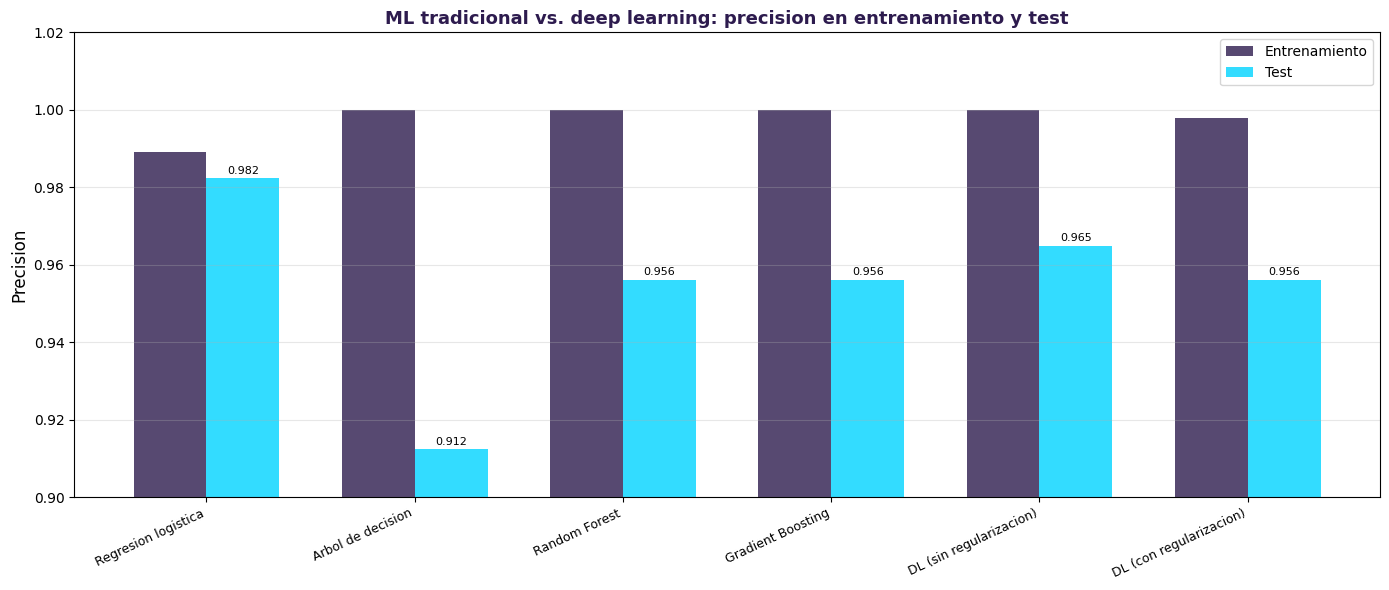

In [30]:
# Grafico de barras comparativo
fig, ax = plt.subplots(figsize=(14, 6))

nombres = list(todos.keys())
accs_test = [todos[n]['test'] for n in nombres]
accs_train = [todos[n]['train'] for n in nombres]

x = np.arange(len(nombres))
width = 0.35

bars1 = ax.bar(x - width/2, accs_train, width, label='Entrenamiento',
               color=PURPLE, alpha=0.8)
bars2 = ax.bar(x + width/2, accs_test, width, label='Test',
               color=CYAN, alpha=0.8)

ax.set_ylabel('Precision', fontsize=12)
ax.set_title('ML tradicional vs. deep learning: precision en entrenamiento y test',
             fontsize=13, fontweight='bold', color=PURPLE)
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=25, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0.90, 1.02)
ax.grid(True, alpha=0.3, axis='y')

# Anotar valores de test sobre las barras
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### Leccion clave para tomadores de decisiones

En este dataset (569 muestras, datos estructurados), **ML tradicional funciona igual de bien** que deep learning, y a veces mejor. Esto nos enseña que:

1. **Deep learning no siempre es la respuesta.** Para datos tabulares con pocas muestras, modelos como Gradient Boosting o Random Forest son excelentes.

2. **Deep learning brilla con datos no estructurados** (imagenes, texto, audio) y grandes volumenes de datos (miles a millones de muestras).

3. **La regularizacion es indispensable.** Sin ella, el deep learning tiende a sobreajustarse, especialmente con pocos datos.

4. **El costo importa.** Entrenar esta red neuronal requirio GPU y mas tiempo que un Random Forest que entrena en milisegundos.

---

## 6. Aplicaciones del deep learning por dominio (2025-2026)

Cerremos con un panorama de las aplicaciones mas impactantes del deep learning en la actualidad. Estas no son proyecciones futuras: son implementaciones reales en produccion.

| Dominio | Ejemplo | Impacto medible |
|---|---|---|
| **Salud** | PathAI (patologia con CNNs) | 5 millones de slides procesados |
| **Finanzas** | Quantexa (GNNs para AML) | Lider en Chartis 2025 |
| **Retail** | Netflix (recomendaciones con DNNs) | 80% de horas vistas provienen de recomendaciones |
| **Manufactura** | Intel (inspeccion visual con DL) | ROI de 1,900%, ahorro de $2M/anio |
| **Agricultura** | John Deere See & Spray (CNNs) | 90% reduccion en uso de herbicidas |
| **Transporte** | Waymo (CNNs + Transformers) | 450,000+ viajes pagados/semana (Q1 2026) |
| **Educacion** | Khan Academy / Khanmigo (GPT-4) | 500+ distritos escolares |
| **Energia** | Google DeepMind (RL profundo) | 6% reduccion energetica en data centers |

### En Costa Rica

| Empresa/Entidad | Aplicacion |
|---|---|
| **Boston Scientific CR** | Algoritmos de IA para desfibriladores implantables |
| **Johnson Controls CR** | Centro de excelencia con digital twins e IA |
| **Colono Agropecuario** | ML y drones para agricultura de precision |
| **ENIA 2024-2027** | Estrategia Nacional de IA (primera en Centroamerica) |

Costa Rica ocupa el **5to lugar** en el Indice Latinoamericano de IA (ILIA) 2025.

## 7. Herramientas interactivas para seguir explorando

Estas plataformas web gratuitas permiten experimentar con redes neuronales sin escribir codigo:

| Herramienta | URL | Para que sirve |
|---|---|---|
| **TensorFlow Playground** | playground.tensorflow.org | Experimentar con learning rate, capas, activaciones, regularizacion |
| **Deeper Playground** | deeperplayground.org | Todo lo anterior + dropout configurable y momentum |
| **Google Teachable Machine** | teachablemachine.withgoogle.com | Entrenar modelos de imagen/sonido/pose directamente en el navegador |
| **MLU-Explain (Amazon)** | mlu-explain.github.io | Articulos interactivos sobre conceptos de ML |
| **CNN Explainer (Georgia Tech)** | poloclub.github.io/cnn-explainer | Visualizar como funciona una CNN procesando imagenes |

**Recomendacion:** Dediquen 15 minutos a TensorFlow Playground o Deeper Playground. Intenten:
1. Resolver el dataset "espiral" solo con 1 capa oculta (no se puede)
2. Agregar capas y ver como mejora
3. Subir el learning rate a 10 y observar que pasa
4. Activar dropout en Deeper Playground y ver el efecto en overfitting

---
## 8. Resumen ejecutivo de la sesion

### Conceptos clave

1. **ML tradicional vs. deep learning** no es una competencia: son herramientas complementarias. La eleccion depende del tipo de datos, volumen, presupuesto y requisitos regulatorios.

2. **Redes neuronales profundas** pueden aprender patrones arbitrariamente complejos, pero requieren mas datos, computo y cuidado para evitar sobreajuste.

3. **Optimizacion** (learning rate, batch size, optimizador) determina si la red aprende eficientemente o fracasa. Un learning rate mal elegido puede arruinar cualquier arquitectura.

4. **Regularizacion** (dropout, batch normalization, early stopping) es indispensable para que el modelo generalice a datos nuevos.

5. **El deep learning transforma industrias reales:** salud, finanzas, manufactura, agricultura. Costa Rica, con su ecosistema de dispositivos medicos y su ENIA 2024-2027, esta posicionada para capitalizar esta tecnologia.

### Para la proxima actividad

Ahora trabajaran en equipos el **Caso 9: MedPrecision S.A.**, donde aplicaran todos estos conceptos a una decision de negocio real sobre inspeccion de calidad con deep learning en una empresa de dispositivos medicos en Costa Rica.

---
*Fundamentos de IA y Machine Learning (92-0025) | ULACIT | Semana 10*